<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

## Mecânica dos Sólidos I

# I.4 Tensão tangencial máxima. Círculo de Mohr.

## Problema 2 <a name="PI42"></a>

Considere o estado de tensão indicado na Figura.

[a)](#A) Determine dois valores de $\sigma_{22}$ para os quais a tensão de corte máxima é 80 MPa.

[b)](#B) Trace os diagramas de Mohr para os dois estados de tensão obtidos na alínea anterior.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au04/Au04_P002_i1.jpg"
width="350" height="220">


## Resolução

#### a) Determine dois valores de $\sigma_{22}$ para os quais a tensão de corte máxima é 80 MPa.<a name="A"></a>

([enunciatum](#PI42))

O estado de tensão é expresso no referencial enunciado pela seguinte matriz de tensão:

\begin{equation*}
\sigma_{ji} = [\sigma]^\top =
\begin{bmatrix}
\sigma_{11} & \tau_{21} & \tau_{31} \\
\tau_{12} & \sigma_{22} & \tau_{32} \\
\tau_{13} & \tau_{23} & \sigma_{33}
\end{bmatrix} =
\begin{bmatrix}
90 & 0 & 60 \\
0 & \sigma_{yy} & 0 \\
60 & 0 & 0
\end{bmatrix}
\end{equation*}


PLANO x-z:
  Tensão normal mínima:  -30.0
  Tensão normal máxima:  120.0
  Tensão normal média :  45.0
Tensão de corte mínima:  -75.0
Tensão de corte máxima:  75.0


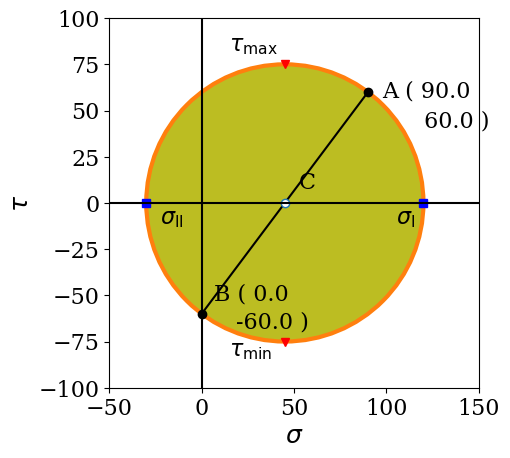

In [1]:
import numpy as np
np.set_printoptions(precision=3, suppress=True)

import matplotlib.pyplot as plt
from matplotlib import rcParams, rc
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 16
# rc('text', usetex=True)

def mohr(S,limits):
    """Plot Mohr circle for a 2D tensor"""
    S11 = S[0][0]
    S12 = S[0][1]
    S22 = S[1][1]
    center = [(S11 + S22)/2.0, 0.0]
    radius = np.sqrt((S11 - S22)**2/4.0 + S12**2)
    Smin = center[0] - radius
    Smax = center[0] + radius

    print("  Tensão normal mínima: ", np.round(Smin,6))
    print("  Tensão normal máxima: ", np.round(Smax, 6))
    print("  Tensão normal média : ", np.round(center[0], 6))
    print("Tensão de corte mínima: ", np.round(-radius, 6))
    print("Tensão de corte máxima: ", np.round(radius, 6))

    circ = plt.Circle((center[0],0), radius, facecolor='tab:olive', lw=3,
    edgecolor='tab:orange')
    desv = 0.1*radius
    plt.axis('image')
    ax = plt.gca()
    ax.add_artist(circ)
    ax.set_xlim(Smin - .3*radius, Smax + .3*radius)
    ax.set_ylim(-1.3*radius, 1.3*radius)
    plt.plot([S11, S22], [S12, -S12], 'ko')
    plt.plot([S11, S22], [S12, -S12], 'k')
    plt.plot(Smin, 0, 'bs')
    plt.plot(Smax, 0, 'bs')
    plt.plot(center[0], radius, 'rv')
    plt.plot(center[0], -radius, 'rv')
    plt.plot(center[0], center[1], 'o', mfc='w')
    plt.text(center[0]+desv, desv, 'C')
    plt.text(S11 + 1.*desv, S12 - .4*desv , 'A ( %3.1f ' % S11)
    plt.text(S11 + 3.5*desv, S12 - 2.5*desv , ' %3.1f )' % S12)
    plt.text(S22 + .9*desv, -S12 + desv, 'B ( %3.1f ' % S22)
    plt.text(S22 + 2.5*desv, -S12 - 1*desv, '%3.1f ) ' % -S12)
    plt.text(Smin + .1*radius, -0.15*radius, r'$\sigma_\mathrm{II}$')
    plt.text(Smax - .2*radius, -0.15*radius, r'$\sigma_\mathrm{I}$')
    plt.text(center[0]-4*desv, 1.1*radius, r'$\tau_\mathrm{max}$')
    plt.text(center[0]-4*desv, -1.1*radius, r'$\tau_\mathrm{min}$')
    plt.xlabel(r"$\sigma$", size=18)
    plt.ylabel(r"$\tau$", size=18)
    plt.xlim(limits[0,0],limits[0,1])
    plt.ylim(limits[1,0],limits[1,1])
    ax.axhline(y=0, color='k')
    ax.axvline(x=0, color='k')
    plt.show()

axislim = np.array([[-50,150],[-100,100]])
print('\n================================')
print('PLANO x-z:')
print('================================')
sxx, szz, sxz = 90, 0, 60
S = np.array([[sxx, sxz],[sxz, szz]])
mohr(S, axislim)

#### b) Trace os diagramas de Mohr para os dois estados de tensão obtidos na alínea anterior.<a name="B"></a>

([enunciatum](#PI42))

##### Caso I

\begin{equation*}
\begin{aligned}
\sigma_\mathrm{I} &= 120~\textrm{MPa} \\
\sigma_\mathrm{II} &= -30~\textrm{MPa} \\
\sigma_\mathrm{III} &=~? \\
\end{aligned}
\end{equation*}

\begin{equation*}
\begin{aligned}
\tau_\mathrm{max} &= \frac{1}{2}(\sigma_\mathrm{I}-\sigma_\mathrm{III})
= 80~\textrm{MPa} \Leftrightarrow \sigma_\mathrm{III} = \sigma_\mathrm{I} - 2\tau_{\mathrm{max}}
= -40~\textrm{MPa} \\
\end{aligned}
\end{equation*}

##### Caso II

\begin{equation*}
\begin{aligned}
\sigma_\mathrm{I} &= ?~\textrm{MPa} \\
\sigma_\mathrm{II} &= 120~\textrm{MPa} \\
\sigma_\mathrm{III} &= -30~\textrm{MPa} \\
\end{aligned}
\end{equation*}

\begin{equation*}
\begin{aligned}
\tau_\mathrm{max} &= \frac{1}{2}(\sigma_\mathrm{I}-\sigma_\mathrm{III})
= 80~\textrm{MPa} \Leftrightarrow \sigma_\mathrm{I} = \sigma_\mathrm{III} + 2\tau_\mathrm{max}
= 130~\textrm{MPa} \\
\end{aligned}
\end{equation*}

\begin{equation*}
\therefore \sigma_{yy} = 130~\textrm{MPa} \vee \sigma_{yy} = -40~\textrm{MPa}
\end{equation*}

Caso I: 


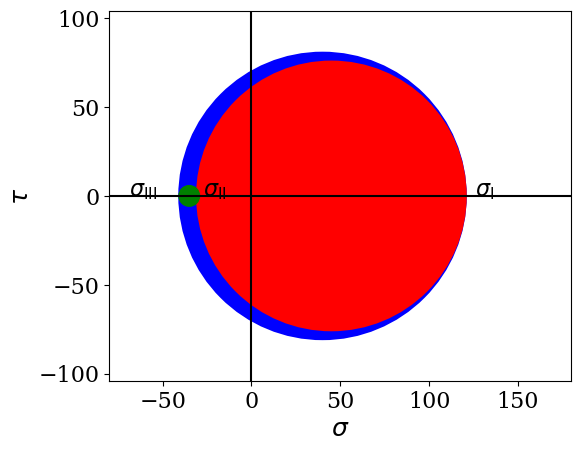

Caso II: 


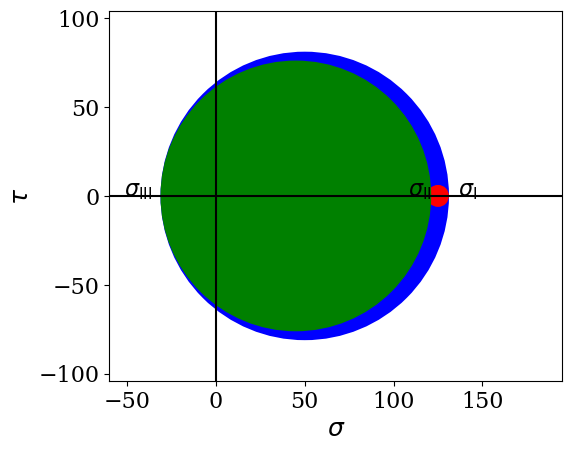

In [3]:
def circleradius(S):
    S11 = S[0,0]
    S12 = S[0,1]
    S22 = S[1,1]

    center = [(S11 + S22)/2.0, 0.0]
    radius = np.sqrt((S11 - S22)**2/4.0 + S12**2)

    return center, radius

def plotC(sigI,sigII,sigIII):
    s11 = sigI; s22 = sigIII; s12 = 0
    S = np.array([[s11, s12],[s12, s22]])
    center1, radius1  = circleradius(S)

    s11 = sigI; s22 = sigII; s12 = 0
    S = np.array([[s11, s12],[s12, s22]])
    center2, radius2  = circleradius(S)

    s11 = sigII; s22 = sigIII; s12 = 0
    S = np.array([[s11, s12],[s12, s22]])
    center3, radius3  = circleradius(S)

    circ1 = plt.Circle((center1[0],0), radius1, facecolor='b', lw=3,
        edgecolor='b')

    circ2 = plt.Circle((center2[0],0), radius2, facecolor='r', lw=3,
        edgecolor='r')

    circ3 = plt.Circle((center3[0],0), radius3, facecolor='g', lw=3,
        edgecolor='g')

    plt.axis('image')
    ax = plt.gca()

    plt.gcf().gca().add_artist(circ1)
    plt.gcf().gca().add_artist(circ2)
    plt.gcf().gca().add_artist(circ3)

    ax.set_xlim(2.*sigIII, 1.5*sigI)
    ax.set_ylim(-1.3*radius1, 1.3*radius1)

    plt.xlabel(r"$\sigma$", size=18)
    plt.ylabel(r"$\tau$", size=18)

    plt.text(1.05*sigI, 0, r'$\sigma_\mathrm{I}$')
    plt.text(.9*sigII, 0, r'$\sigma_\mathrm{II}$')
    plt.text(1.72*sigIII, 0, r'$\sigma_\mathrm{III}$')

    ax.axhline(y=0, color='k')
    ax.axvline(x=0, color='k')

    plt.show()

print('=========================================================')
print('Caso I: ')
print('=========================================================')

sigI, sigII, sigIII = 120, -30, -40
plotC(sigI,sigII,sigIII)

print('=========================================================')
print('Caso II: ')
print('=========================================================')

sigI, sigII, sigIII = 130, 120, -30
plotC(sigI,sigII,sigIII)


---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>